<a href="https://colab.research.google.com/github/hparupudi/ForeCAT/blob/main/WindShear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Selenium, OpenAI setup
!pip install selenium
!apt-get update
!apt-get install -y chromium-browser
!apt install chromium-chromedriver
!ls /usr/lib/chromium-browser/chromedriver
!pip install openai

In [ ]:
#Load Plymouth available locations w/data into structured dictionary
import pandas as pd
import numpy as np

plymouth_data = pd.read_excel("Copy of Plymouth US Available Data.xlsx")
plymouth_regions = plymouth_data['Map Region'].unique()
plymouth_dict = {
    region: {
      row['Municipality']: {
          'Latitude': row['Latitude'],
          'Longitude': row['Longitude'],
          'Pixel X': row['Pixel X'],
          'Pixel Y': row['Pixel Y'],
          'Ground Elevation': row['Ground Elevation (ft)']
      } for _, row in plymouth_data[plymouth_data['Map Region'] == region].iterrows()
    }
    for region in plymouth_regions
}

#Function to find region
def find_regions(data):
  regions = []
  region_names = [item for item in plymouth_dict.keys()]
  for x in range(len(data)):
    location = data['Data Location'].to_numpy()[x]
    for region in region_names:
      if location in plymouth_dict[region]:
        regions.append(region)
        break

  return regions

'''data['Region'] = find_regions(data)
altitudes = [altitude / 3.28084 for altitude in data['Altitude']]
data['Atmospheric Pressure'] = [round(1013.25 * np.pow(1 - altitude / 44330.77, 5.255), 0) for altitude in altitudes]
intervals = [150, 200, 250, 300, 400, 500]
lowerP, upperP = [], []

for pressure in data['Atmospheric Pressure']:
  for x in range(len(intervals) - 1):
    if intervals[x] <= pressure and pressure < intervals[x+1]:
      upperP.append(intervals[x])
      lowerP.append(intervals[x+1])
data['LowerP'], data['UpperP'] = lowerP, upperP'''


def altitude_distance(lowerP, upperP):
  lowerA = round(44330.77 * 3.28084 * (1 - np.pow((lowerP / 1013.25), (1/5.255))), 0) #Pressure (mb) -> Altitude (ft)
  upperA = round(44330.77 * 3.28084 * (1 - np.pow((upperP / 1013.25), (1/5.255))), 0) #Pressure (mb) -> Altitude (ft)
  return upperA - lowerA #Altitude difference in feet

#data['Altitude Delta'] = altitude_distance(data['LowerP'], data['UpperP'])
#data.to_excel('NoTurbulenceData.xlsx')

In [ ]:
import numpy as np
import pandas as pd

#Format data and store in arrays
data = pd.read_excel("final_turbulence_trainingv3.xlsx", index_col=0)
years = data['Year'].to_numpy()
months = data['Month'].to_numpy()
days = data['Day'].to_numpy()
times = data['Time'].to_numpy()
regions = data['Region'].to_numpy()
data_locs = data['Data Location'].to_numpy()
latitudes = data['Latitude'].to_numpy()
longitudes = data['Longitude'].to_numpy()
#lower_pressures = data['LowerP'].to_numpy()
#upper_pressures = data['UpperP'].to_numpy()

'''lowerS_arr = [item for item in list(data['Lower S2']) if np.isnan(item) == False]
lowerD_arr= [item for item in list(data['Lower D2']) if np.isnan(item) == False]
lowerT_arr = [item for item in list(data['Lower T2'])if np.isnan(item) == False]
upperS_arr = [item for item in list(data['Upper S2']) if np.isnan(item) == False]
upperD_arr = [item for item in list(data['Upper D2'])if np.isnan(item) == False]
upperT_arr = [item for item in list(data['Upper T2'])if np.isnan(item) == False]'''

lowerS_arr, lowerD_arr, upperS_arr, upperD_arr, lowerT_arr, upperT_arr = [], [], [], [], [], []

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
months = [month_names[month - 1] for month in months]

dist_arr = np.zeros(shape=(len(data), 4))

In [ ]:
#import pytesseract
import cv2
from PIL import Image
#from pytesseract import Output
import math
import base64
from google.colab import userdata
from openai import OpenAI

counter = []

def format_img(img, img_num):
    data_pixels = []
    left_x, right_x = 10, 900
    top_y, bottom_y = 50, 640

    width, height = img.size
    #pixel_X = pixels_X[img_num]
    #pixel_Y = pixels_Y[img_num]
    #constant = region_dict[regions[img_num]]
    pixel_X = plymouth_dict[regions[img_num]][data_locs[img_num]]['Pixel X']
    pixel_Y = plymouth_dict[regions[img_num]][data_locs[img_num]]['Pixel Y']
    constant = 50
    directions = [pixel_X - constant, pixel_Y - constant, pixel_X + constant, pixel_Y + constant]

    for x in range(len(directions)):
      if x % 2 == 0:
        if directions[x] < left_x:
          directions[x] = left_x
        elif directions[x] > right_x:
          directions[x] = right_x
      else:
        if directions[x] < top_y:
          directions[x] = top_y
        elif directions[x] > bottom_y:
          directions[x] = bottom_y

    rgb_img = img.convert('RGB')

    for x in range(width):
      for y in range(height):
        r, g, b = rgb_img.getpixel((x, y))
        if r > 150 and g < 10 and b < 10:
          rgb_img.putpixel((x, y), (255, 255, 255))

    for x in range(width):
      for y in range(height):
        r, g, b = rgb_img.getpixel((x, y))
        if r < 255 or g < 255 or b < 255:
          rgb_img.putpixel((x, y), (0, 0, 0))

    cropped_img = rgb_img.crop((directions[0], directions[1], directions[2], directions[3]))
    return cropped_img

def get_data(img, img_num, data_type):
  curr_coords = []
  newStr = []
  options = "--psm 11"

  cropped_img = format_img(img, img_num)
  width, height = cropped_img.size
  center = [width / 2, height / 2]

  buffered = io.BytesIO()
  cropped_img.save(buffered, format='PNG')
  img_bytes = buffered.getvalue()
  base64_str = base64.b64encode(img_bytes).decode('utf-8')

  client = OpenAI(api_key=userdata.get('OpenAI_API'))
  completion = client.chat.completions.create(
      model="gpt-5-mini",
      messages=[
        {
            "role": "user",
            "content": [
                { "type": "text", "text": '''Find the numerical value closest to the center of the image.
                Output the numerical value only in integer form, nothing else. If there is no visible numeric
                value anywhere in the image, the value is 0.'''},
                {
                  "type": "image_url",
                  "image_url": {
                      "url": f"data:image/jpeg;base64,{base64_str}",
                  }
                }
            ]
        }
      ],
  )

  val = completion.choices[0].message.content
  if data_type == 0: lowerS_arr.append(val)
  elif data_type == 1: upperS_arr.append(val)
  elif data_type == 2: lowerD_arr.append(val)
  elif data_type == 3: upperD_arr.append(val)
  elif data_type == 4: lowerT_arr.append(val)
  else: upperT_arr.append(val)

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select, WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from PIL import Image
import urllib.request
import io
import matplotlib.pyplot as plt
from datetime import datetime
import time

#Configuring selenium webdriver
options = webdriver.ChromeOptions()
options.add_argument('--no-sandbox')
options.add_argument('--headless')
options.add_argument('--disable-gpu')
options.add_argument('--diable-dve-shm-uage')

#Function to find image data
def find_image(region, pressure, attr, year, month, day, time):
  driver = webdriver.Chrome(options=options)
  print('Success')
  url="https://vortex.plymouth.edu/myowxp/upa/pltmap-a.html"
  driver.get(url)

  Select(driver.find_element("name", "re")).select_by_visible_text(f"{region}")
  Select(driver.find_element("name", "le")).select_by_visible_text(f"{pressure}")
  Select(driver.find_element("name", "va")).select_by_visible_text(f"{attr}")
  Select(driver.find_element("name", "yy")).select_by_visible_text(f"{year}")
  Select(driver.find_element("name", "mm")).select_by_visible_text(f"{month}")
  Select(driver.find_element("name", "dd")).select_by_visible_text(f"{day}")
  Select(driver.find_element("name", "hh")).select_by_visible_text(f"{time}")
  Select(driver.find_element("name", "sc")).select_by_visible_text(".7")

  driver.find_element(by=By.TAG_NAME, value='input').click()
  map_img = WebDriverWait(driver, 10).until(
    EC.presence_of_element_located((By.XPATH, "//img[@alt='[GIF]']"))
  )

  map_img = map_img.get_attribute("src")
  driver.quit()
  img = urllib.request.urlopen(map_img).read()
  img = Image.open(io.BytesIO(img))
  return img

#Loop to find data for every location in dataset
for x in range(0, 1):
  start_time = time.time()
  year, month, day, data_time = years[x], months[x], days[x], str(times[x]) + " Z"
  #lower_pressure, upper_pressure = str(lower_pressures[x]) + " mb", str(upper_pressures[x]) + " mb"
  lower_pressure, upper_pressure = "850 mb", "200 mb"
  img = find_image(regions[x], lower_pressure, "Wind Speed", year, month, day, data_time)
  get_data(img, x, 0)
  img2 = find_image(regions[x], upper_pressure, "Wind Speed", year, month, day, data_time)
  get_data(img2, x, 1)
  img3 = find_image(regions[x], lower_pressure, "Wind Direction", year, month, day, data_time)
  get_data(img3, x, 2)
  img4 = find_image(regions[x], upper_pressure, "Wind Direction", year, month, day, data_time)
  get_data(img4, x, 3)
  img5 = find_image(regions[x], lower_pressure, "Temperature", year, month, day, data_time)
  get_data(img5, x, 4)
  img6 = find_image(regions[x], upper_pressure, "Temperature", year, month, day, data_time)
  get_data(img6, x, 5)
  print(f"Time for {x}. {time.time() - start_time}")
#width, height = img.size
#print(width, height)

SessionNotCreatedException: Message: session not created: Chrome instance exited. Examine ChromeDriver verbose log to determine the cause.; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#sessionnotcreatedexception
Stacktrace:
#0 0x5aa2ac1fe16a <unknown>
#1 0x5aa2abc7bc4b <unknown>
#2 0x5aa2abcb5d1d <unknown>
#3 0x5aa2abcb16d3 <unknown>
#4 0x5aa2abd0124c <unknown>
#5 0x5aa2abd0096c <unknown>
#6 0x5aa2abcbfc42 <unknown>
#7 0x5aa2abcc08f1 <unknown>
#8 0x5aa2ac1c6f09 <unknown>
#9 0x5aa2ac1c9e4d <unknown>
#10 0x5aa2ac1afc51 <unknown>
#11 0x5aa2ac1caa2b <unknown>
#12 0x5aa2ac196a20 <unknown>
#13 0x5aa2ac1eba78 <unknown>
#14 0x5aa2ac1ebc49 <unknown>
#15 0x5aa2ac1fd4c3 <unknown>
#16 0x0f76f6d3aac3 <unknown>


In [ ]:
#Fix data type in arrays
lowerS_arr = [int(item) for item in lowerS_arr]
lowerD_arr = [int(item) for item in lowerD_arr]
upperS_arr = [int(item) for item in upperS_arr]
upperD_arr = [int(item) for item in upperD_arr]
lowerT_arr = [int(item) for item in lowerT_arr]
upperT_arr = [int(item) for item in upperT_arr]

#Add wind speed and direction values to dataset + download dataset
for x in range(len(lowerS_arr)):
  data['Lower S2'][x] = lowerS_arr[x]
  data['Lower D2'][x] = lowerD_arr[x]
  data['Upper S2'][x] = upperS_arr[x]
  data['Upper D2'][x] = upperD_arr[x]
  data['Lower T2'][x] = lowerT_arr[x]
  data['Upper T2'][x] = upperT_arr[x]

data.to_excel('final_turbulence_trainingv3.xlsx')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

#Initialize vector map & windshear dataframe
vectorMap = []
windshear = []

def degtoBearing (angle): #Turns degrees into bearing angles
    #Want to : [0, 45, 90, 135, 180, 225, 270, 315, 0] - > [90, 45, 0, 315, 270, 225, 180, 135, 90]
    angle = angle % 360 #Corresponding angle from 0-359
    bearingAngle = 360 - angle #[0, 45, 90, 135, 180, 225, 270, 315, 0] -> [360, 315, 270, 225, 180, 135, 90, 45, 360]
    bearingAngle = bearingAngle - 270 #[360, 315, 270, 225, 180, 135, 90, 45, 360] -> [90, 45, 0, -45, -90, -135, -180, -225, 90]

    if bearingAngle < 0: #If negative
      bearingAngle = bearingAngle + 360 #[90, 45, 0, -45, -90, -135, -180, -225, 90] -> [90, 45, 0, 315, 270, 225, 180, 135, 90]

    return bearingAngle

def bearingtoDeg (bearingAngle): #Turns bearing angles into degrees
    #Want to : [90, 45, 0, 315, 270, 225, 180, 135, 90] - > [0, 45, 90, 135, 180, 225, 270, 315, 0]
    bearingAngle = bearingAngle % 360 #Corresponding angle from 0-359
    angle = 360 - bearingAngle #[90, 45, 0, 315, 270, 225, 180, 135, 90] -> [270, 335, 360, 45, 90, 135, 180, 225, 270]
    angle = angle - 270 #[270, 335, 360, 45, 90, 135, 180, 225, 270] -> [0, 45, 90, -225, -180, -135, -90, -45, 0]

    if angle < 0: #If negative
      angle = angle + 360 #[0, 45, 90, -225, -180, -135, -90, -45, 0] -> [0, 45, 90, 135, 180, 225, 270, 315, 0]

    return angle

def windShear (lowerS, lowerD, upperS, upperD): #Calculate wind shear
    lowerD = np.deg2rad(bearingtoDeg(lowerD)) #Turns bearing to rad
    lowerD = np.array([np.cos(lowerD), np.sin(lowerD)]) #Turns into unit vector
    upperD = np.deg2rad(bearingtoDeg(upperD)) #Turns bearing to rad
    upperD = np.array([np.cos(upperD), np.sin(upperD)]) #Turns into unit vector

    lowerV = lowerD * lowerS #Lower wind vector
    upperV = upperD * upperS #Upper wind vector

    windShear = upperV - lowerV, #Wind shear: Difference in wind vectors
    for i in range(len(windShear)):
      windShear[i] = round(windShear[i], 2)

    return windShear

def dataArray (lowerS, lowerD, upperS, upperD, num):
  #for i in range(len(lowerS)):
    currWindShear = windShear(lowerS, lowerD, upperS, upperD) #Calculate wind shear
    locNShear = np.array([])
    locNShear = np.append(locNShear, currWindShear) #[x Shear, y Shear]
    #locNShear = np.append(locNShear, coords[0]) #[x Shear, y Shear, lat, long]
    vectorMap[num] = locNShear #Replace 0s with [x Shear, y Shear, lat, long]
    #locationMap(num)

def locationMap(loc):
  plt.figure(figsize=(10, 7))
  if np.linalg.norm(np.array([vectorMap[loc][0], vectorMap[loc][1]])) != 0: #If magnitude not 0
    plt.arrow(vectorMap[loc][2], vectorMap[loc][3], vectorMap[loc][0], vectorMap[loc][1], width = .5)
    #plt.savefig(fname=f'/content/drive/MyDrive/Non-CAT Dataset/{loc}.png')

def computeVector():
  dir = []
  mag = []

  for i in range(len(windshear)):
    dir.append(round((np.arctan(windshear['Y'][i] / windshear['X'][i])) * 180 / math.pi, 2))
    mag.append(round(math.sqrt(math.pow(windshear['X'][i], 2) + math.pow(windshear['Y'][i], 2)), 2))

  return [mag, dir]

def findVector(length, lowerS, lowerD, upperS, upperD, lowerT, upperT):
  global vectorMap, windshear
  vectorMap = np.zeros([length, 2])
  for num in range(0, length):
    dataArray(lowerS[num], lowerD[num], upperS[num], upperD[num], num)
  windshear = pd.DataFrame(vectorMap)
  windshear.columns = ['X', 'Y']
  mag_dir = computeVector()
  vectorMap = np.swapaxes(vectorMap, 0, 1)
  deltaS = abs(np.array(lowerS) - np.array(upperS)) #Absolute difference between wind speed (knots)
  deltaD = abs(np.array(lowerD) - np.array(upperD)) #Absolute difference between wind direction (degrees)
  deltaT = np.array(upperT) - np.array(lowerT) #Difference between temperature (Celsius)
  deltaD = np.array([360 - item if item > 180 else item for item in deltaD])
  data = pd.DataFrame({"DeltaS2": deltaS, "DeltaD2": deltaD,
                       "DeltaT2": deltaT, "X2": vectorMap[0], "Y2": vectorMap[1],
                       "Magnitude2": mag_dir[0], "Direction2": mag_dir[1]})
  return data
  #path = time + "_" + data_type + "_" + dimension + ".xlsx"
  #data.to_excel(path)

'''#Add Windshear data to dataset
new_data = findVector(len(lowerS_arr), lowerS_arr, lowerD_arr, upperS_arr, upperD_arr, lowerT_arr, upperT_arr)
data.update(new_data)'''

'#Add Windshear data to dataset\nnew_data = findVector(len(lowerS_arr), lowerS_arr, lowerD_arr, upperS_arr, upperD_arr, lowerT_arr, upperT_arr)\ndata.update(new_data)'

Text(0.5, 1.0, 'Windshear X vs. Windshear Y')

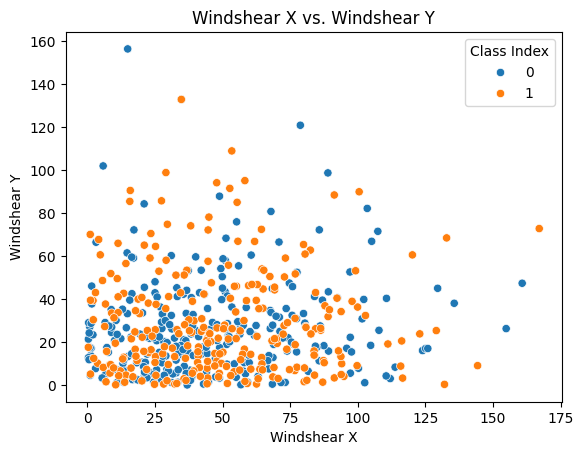

In [ ]:
#Comparing Windshear X vs. Windshear Y for all 4 turbulence thresholds
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = pd.read_excel('final_turbulence_trainingv3.xlsx', index_col=0)
X_label, Y_label = 'Windshear X', 'Windshear Y'
abs_X = [abs(item) for item in data['X2']]
abs_Y = [abs(item) for item in data['Y2']]
scatterplot = sns.scatterplot(x=abs_X, y=abs_Y, hue=data['Class Index'])
plt.xlabel(f"{X_label}")
plt.ylabel(f"{Y_label}")
plt.title(f"{X_label} vs. {Y_label}")

In [ ]:
#Visualize data trends
import numpy as np
import pandas as pd

#data = pd.read_excel('/content/final_turbulence_trainingv2.xlsx', index_col=0)

def find_average(data, class_names):
  avg_data = pd.DataFrame(index=class_names, columns=['Avg Delta S', 'Avg Delta D', 'Avg Delta T', 'Avg X', 'Avg Y', 'Avg Mag', 'Avg Dir'])

  for x in range(len(class_names)):
    avg_deltaS = np.mean(data[data['Class Index'] == class_names[x]]['DeltaS2'].to_numpy())
    avg_deltaD = np.mean(data[data['Class Index'] == class_names[x]]['DeltaD2'].to_numpy())
    avg_deltaT = np.mean(data[data['Class Index'] == class_names[x]]['DeltaT2'].to_numpy())
    avg_X = np.mean(data[data['Class Index'] == class_names[x]]['X2'].to_numpy())
    avg_Y = np.mean(data[data['Class Index'] == class_names[x]]['Y2'].to_numpy())
    avg_mag = np.mean(data[data['Class Index'] == class_names[x]]['Magnitude2'].to_numpy())
    avg_dir = np.mean(data[data['Class Index'] == class_names[x]]['Direction2'].dropna().to_numpy())
    avg_data.loc[class_names[x]] = [avg_deltaS, avg_deltaD, avg_deltaT, avg_X, avg_Y, avg_mag, avg_dir]

  return avg_data

class_names = [x for x in range(2)]
avg_data = find_average(data, class_names)
avg_data

,Avg Delta S,Avg Delta D,Avg Delta T,Avg X,Avg Y,Avg Mag,Avg Dir
0,46.159011,61.55477,-64.427562,-44.583604,1.521731,57.054064,0.510954
1,52.114943,50.877395,-59.099617,-47.64636,-1.697854,62.640536,1.361571


In [ ]:
data = pd.read_excel('final_turbulence_trainingv2.xlsx', index_col=0)
data = data.dropna().reset_index(drop=True)

drop_cols = [item for item in data.columns][:12]
drop_cols.extend(['Class Index', 'Altitude Delta', 'LowerP', 'UpperP'])
drop_cols.remove('Altitude')
cols = ['DeltaS', 'DeltaD', 'DeltaT', 'X', 'Y', 'Magnitude', 'Direction']
for col in cols:
  data[col] = [data[col][x] / data['Altitude Delta'][x] for x in range(len(data))]
features = data.drop(drop_cols, axis=1)
target = data['Class Index']

Index(['Year', 'Month', 'Day', 'Time', 'Latitude', 'Longitude', 'Altitude',
       'EDR * 100', 'Distance to Data', 'Data Location', 'Class', 'Region',
       'Lower S', 'Upper S', 'Lower D', 'Upper D', 'Lower T', 'Upper T',
       'Atmospheric Pressure', 'LowerP', 'UpperP', 'Altitude Delta', 'DeltaS',
       'DeltaD', 'DeltaT', 'X', 'Y', 'Magnitude', 'Direction', 'Class Index'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

data = pd.read_excel('final_turbulence_trainingv3.xlsx', index_col=0).sort_values(by=['Class Index', 'Year', 'Month', 'Day', 'Time'], ascending=True).reset_index(drop=True)
drop_cols = [item for item in data.columns][:12]
drop_cols.remove('Altitude')
drop_cols.extend(['Class Index', 'Altitude Delta'])
features = data.drop(drop_cols, axis=1)
target = data['Class Index']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target, random_state=42)
model = RandomForestClassifier(n_estimators=150, max_depth=18, min_samples_split=5, random_state=42)
#model = RandomForestClassifier(n_estimators=150, max_depth=18, min_samples_split=5, random_state=42)
'''model = XGBClassifier(n_estimators=100,
                      learning_rate=0.17,
                      max_depth=4,
                      max_leaves=10,
                      random_state=42)'''
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
y_test = y_test.to_numpy()


train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
test_report = classification_report(y_test, y_pred)
#test_report = pd.DataFrame(test_report).transpose()

print(f"Train Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")
print(f"AUC score: {roc_auc}")
print(test_report)

Train Accuracy: 1.0
Test Accuracy: 0.7714285714285715
AUC score: 0.841799709724238
              precision    recall  f1-score   support

           0       0.78      0.75      0.77        53
           1       0.76      0.79      0.77        52

    accuracy                           0.77       105
   macro avg       0.77      0.77      0.77       105
weighted avg       0.77      0.77      0.77       105



In [ ]:
model = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_split=3, random_state=42)
'''model = XGBClassifier(n_estimators=100,
                      learning_rate=0.17,
                      max_depth=4,
                      max_leaves=10,
                      random_state=42)'''
pred_prob_arr, y_pred_arr, y_true_arr, fi_arr = cross_validate(model, 10)
test_report = classification_report(y_true_arr, y_pred_arr)
auc = roc_auc_score(y_true_arr, pred_prob_arr)
accuracy = round(len([x for x in range(len(y_true_arr)) if y_true_arr[x] == y_pred_arr[x]]) / len(y_true_arr), 2)
print(f"Cross validated test accuracy: {accuracy}, Cross validated test AUC: {auc}")
print(test_report)

Cross validated test accuracy: 0.76, Cross validated test AUC: 0.8380381967381572
              precision    recall  f1-score   support

           0       0.74      0.81      0.78       261
           1       0.79      0.72      0.75       261

    accuracy                           0.76       522
   macro avg       0.77      0.76      0.76       522
weighted avg       0.77      0.76      0.76       522



In [ ]:
#Model Feature Importances
feature_importances = pd.DataFrame({'Feature': features.columns, 'Importance': fi_arr})
feature_importances = feature_importances.sort_values(by=['Importance'], ascending=False).reset_index(drop=True)
feature_importances

,Feature,Importance
0,Altitude,0.134
1,Atmospheric Pressure,0.117
2,DeltaT2,0.056
3,DeltaT,0.040
4,Lower T2,0.037
5,Magnitude,0.035
6,Y2,0.032
7,Lower S,0.032
8,Magnitude2,0.032
9,DeltaS2,0.030


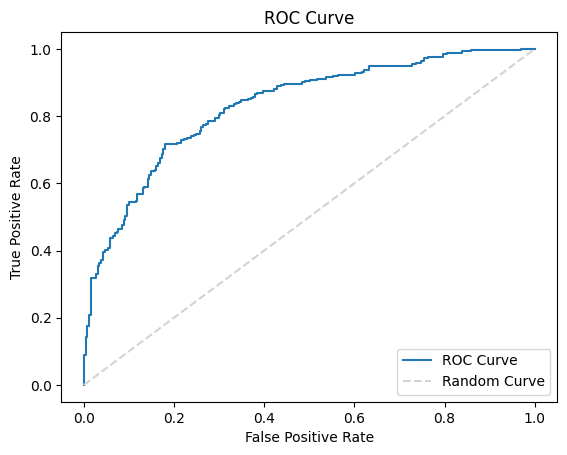

In [ ]:
#Visualize ROC curve
import matplotlib.pyplot as plt
false_pos, true_pos, threshold = roc_curve(y_true_arr, pred_prob_arr, pos_label=1)
plt.plot(false_pos, true_pos, label='ROC Curve')
plt.plot([0, 1], [0, 1], label='Random Curve', color='#D3D3D3', linestyle='dashed')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
import time

#Function to cross-validate model
def cross_validate(model, n_splits):
  pred_prob_arr, y_pred_arr, y_true_arr, fi_arr = [], [], [], np.zeros(len(features.columns))
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  for train_index, test_index in skf.split(features, target):
    X_train, X_test = features.iloc[train_index], features.iloc[test_index]
    y_train, y_test = target.iloc[train_index], target.iloc[test_index]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    feature_importance = model.feature_importances_

    y_pred_arr.extend(y_pred)
    y_true_arr.extend(y_test)
    pred_prob_arr.extend(y_pred_prob)
    fi_arr = [fi_arr[x] + feature_importance[x] for x in range(len(features.columns))]

  fi_arr = [round(fi_arr[x] / n_splits, 3) for x in range(len(features.columns))]
  return pred_prob_arr, y_pred_arr, y_true_arr, fi_arr

In [ ]:
#Grid search to optimize hyperparameters
import time
test_acc_arr, test_auc_arr, params_arr, test_report_arr, feature_importances, counter = [], [], [], [], [], 0

for n_estimators in range(100, 1100, 50):
  for max_depth in range(3, 20):
    for min_samples_split in range(3, 20):
      #for learning_rate in np.arange(0.01, 0.2, 0.01):
        start_time = time.time()
        params = {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'min_samples_split': min_samples_split
        }
        params_arr.append(params)
        model = RandomForestClassifier(n_estimators=n_estimators,
                      max_depth=max_depth,
                      min_samples_split=min_samples_split,
                      random_state=42)
        pred_prob_arr, y_pred_arr, y_true_arr, fi_arr = cross_validate(model, 10)
        test_report = classification_report(y_true_arr, y_pred_arr)
        auc = roc_auc_score(y_true_arr, pred_prob_arr)
        accuracy = round(len([x for x in range(len(y_true_arr)) if y_true_arr[x] == y_pred_arr[x]]) / len(y_true_arr), 2)

        test_acc_arr.append(accuracy)
        test_auc_arr.append(auc)
        test_report_arr.append(test_report)
        feature_importances.append(fi_arr)

        end_time = time.time() - start_time
        print(f"{counter}. Test Accuracy: {accuracy}, Test AUC: {auc}, Total Time: {end_time}")
        '''model.fit(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_pred_prob)

        report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
        test_acc_arr.append(test_acc)
        test_auc_arr.append(test_auc)
        test_report_arr.append(report)

        end_time = time.time() - start_time
        print(f"{counter}. Test Accuracy: {test_acc}, Test AUC: {test_auc}, Total Time: {end_time}")'''
        counter+=1

In [ ]:
results = pd.DataFrame({"Test Accuracy": test_acc_arr, "Test AUC": test_auc_arr})
results = results.sort_values(by=['Test AUC'], ascending=False)
#results[results['Test Accuracy'] >= 0.76].sort_values(by='Test AUC', ascending=False)
results

,Test Accuracy,Test AUC
374,0.76,0.838038
171,0.76,0.836937
384,0.76,0.836776
239,0.76,0.836570
256,0.76,0.836504
...,...,...
10,0.72,0.808752
14,0.72,0.808737
13,0.72,0.808517
16,0.73,0.808503


In [ ]:
params_arr[374]

{'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 3}

Text(33.222222222222214, 0.5, 'Truth')

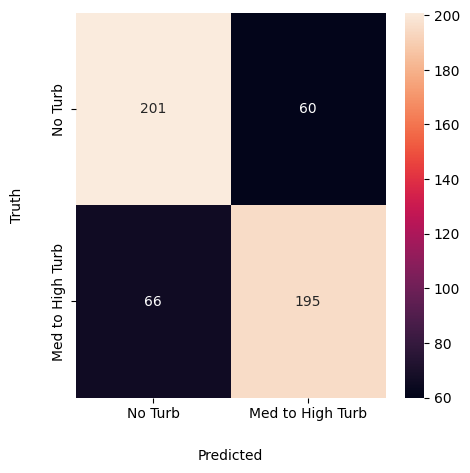

In [ ]:
#Visualize confusion matrix
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
matrix = confusion_matrix(y_true_arr, y_pred_arr)
classes = ["No Turb", "Med to High Turb"]
plt.figure(figsize=(5, 5))
sn.heatmap(matrix, annot=True, xticklabels=classes, yticklabels=classes, fmt='d')
plt.xlabel("Predicted", labelpad=20)
plt.ylabel("Truth", labelpad=20)

In [ ]:
#Save model to be deployed
import pickle
with open("CAT-model-2", "wb") as f:
  pickle.dump(model, f)

In [ ]:
import pickle

#Load model to make predictions
with open("CAT-model-2", "rb") as f:
  model = pickle.load(f)

#Making predictions on sample data
sample_data = pd.DataFrame({'Altitude': [20000],
                            'Lower S': [10],
                            'Upper S': [90],
                            'Lower D': [50],
                            'Upper D': [250],
                            'Lower T': [10],
                            'Upper T': [-50],
                            'Atmospheric Pressure': [238],
                            'LowerP': [200],
                            'UpperP': [250],
                            'DeltaS': [100],
                            'DeltaD': [160],
                            'DeltaT': [-60],
                            'X': [90],
                            'Y': [70],
                            'Magnitude': [100],
                            'Direction': [40],
                            })

model.predict_proba(sample_data)

array([[0.47441724, 0.52558276]])

In [ ]:
#Real Time Predictions
lat, lon = [43.4163, -70.5643]
lowerS, lowerD, upperS, upperD = 20, 340, 55, 20
lowerT, upperT = -30, -70
lowerS2, lowerD2, upperS2, upperD2 = 10, 180, 55, 20
lowerT2, upperT2 = -5, -70

altitude = 4000
altitude_delta = altitude_distance(500, 200)
temp_altitude = altitude / 3.28084
atmospheric_pressure = round(1013.25 * np.pow(1 - temp_altitude / 44330.77, 5.255))

deltaS, deltaS = upperS - lowerS, upperS2 - lowerS2
deltaD, deltaD2 = upperD - lowerD, upperD2 - lowerD2
deltaT, deltaT2 = upperT - lowerT, upperT2 - lowerT2

closest_windshear = windShear(lowerS, lowerD, upperS, upperD)

TypeError: type numpy.ndarray doesn't define __round__ method